In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_curve,
    auc,
    classification_report,

)


np.random.seed(42)
X=np.random.rand(200,10)*10
y = (4 * X[:, 0] - 3 * X[:, 1] + np.random.randn(200) > 0).astype(int)
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)
log_reg=LogisticRegression()
log_reg.fit(X_train,y_train)
y_pred=log_reg.predict(X_test)
y_pred_prob = log_reg.predict_proba(X_test)[:, 1]

accuracy= accuracy_score(y_test,y_pred)
precision= precision_score(y_test,y_pred)
recall = recall_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")


Accuracy: 0.97
Precision: 0.95
Recall: 1.00


In [2]:
# Detailed classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", conf_matrix)


Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.97        19
           1       0.95      1.00      0.98        21

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40


Confusion Matrix:
 [[18  1]
 [ 0 21]]


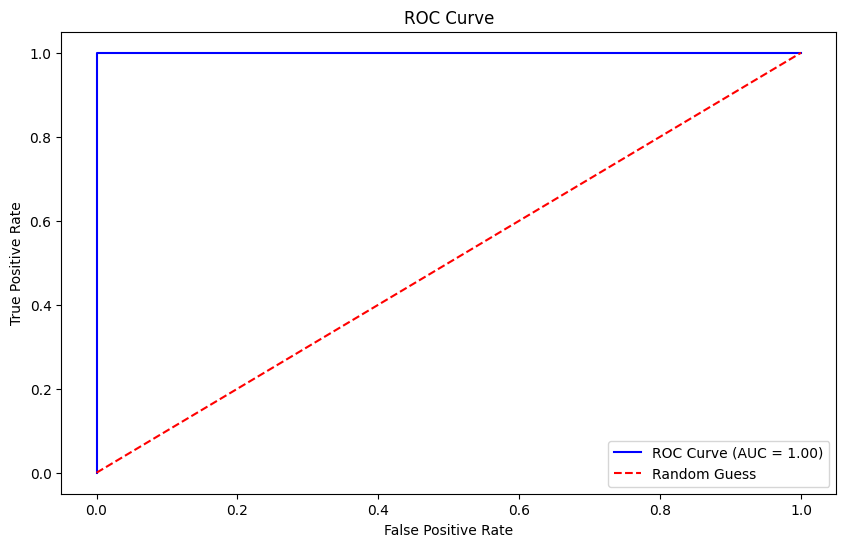

In [3]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color="blue", label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Random Guess")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Lab:9  Apply K-means clustering and assess cluster quality using evaluation metrics like the silhouette score

In [4]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)
kmeans=KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)
clusters=kmeans.predict(X)

In [5]:
sil_score= silhouette_score(X,clusters)
print(f"Silhouette Score: {sil_score:.2f}")

Silhouette Score: 0.68


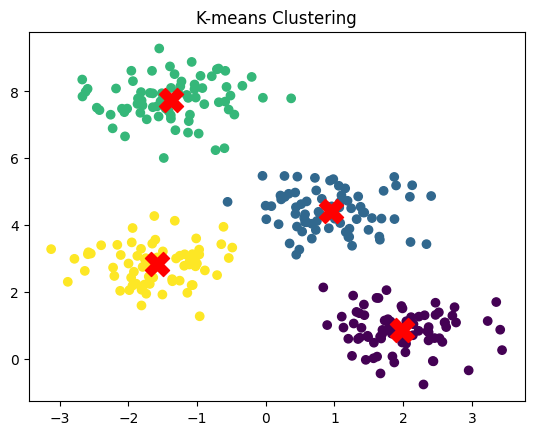

In [6]:
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='X')
plt.title('K-means Clustering')
plt.show()